# Georgian Spellchecker — Data & Training

A character-level **encoder–decoder** sequence-to-sequence model with attention that corrects misspelled Georgian words.

**Architecture overview**
- Bidirectional GRU encoder → captures context from both directions  
- GRU decoder with Bahdanau attention → handles variable output lengths cleanly  
- Trained with teacher forcing + label smoothing  
- Greedy + beam-search decoding at inference time  

## 1. Installs & imports

In [28]:
import os, random, math, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

import kagglehub

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Data collection

The dataset was assembled from Georgian Wikipedia, news corpora, and literature archives.  
**110 734 unique correctly-spelled words** were collected as a vocabulary base.  
Synthetic errors were generated per the methodology described in Section 3 below,  
producing **332 132 (input, target) pairs** — one-third of which have identical input and target  
(i.e. already-correct words) so the model learns to pass through clean input unchanged.

In [29]:
dataset_path = kagglehub.dataset_download('giorgicheishvili/georgian-spellchecker-dataset')
print(f'Dataset downloaded to: {dataset_path}')
print(os.listdir(dataset_path))

Dataset downloaded to: /kaggle/input/datasets/giorgicheishvili/georgian-spellchecker-dataset
['georgian_spellchecker_dataset.csv', 'georgian_vocabulary.txt']


In [30]:
csv_file = os.path.join(dataset_path, 'georgian_spellchecker_dataset.csv')
df = pd.read_csv(csv_file)
print(f'Total pairs : {len(df):,}')
print(f'Columns     : {df.columns.tolist()}')
print(df.head(10))

Total pairs : 332,132
Columns     : ['input_word', 'target_word']
     input_word   target_word
0    მეტრევეელს     მეტრეველს
1       ეთნიკურ       ეთნიკურ
2          რემი          ერმი
3        ჰარჯკი        ჰარუკი
4  დაუნდობლობოს  დაუნდობლობის
5         ჯაჭვი        ჯაჭვში
6     მოუუვიდათ      მოუვიდათ
7      თვითონვე      თვითონვე
8      დმნაისიც      დმანისიც
9        ნახხავ         ნახავ


## 3. Dataset exploration

In [31]:
# Drop any rows with NaN
df = df.dropna().reset_index(drop=True)
df['input_word']  = df['input_word'].astype(str).str.strip()
df['target_word'] = df['target_word'].astype(str).str.strip()

already_correct = (df['input_word'] == df['target_word']).sum()
print(f'Already-correct pairs : {already_correct:,}  ({100*already_correct/len(df):.1f}%)')

df['input_len']  = df['input_word'].str.len()
df['target_len'] = df['target_word'].str.len()
print(f"Input  length — mean {df['input_len'].mean():.1f}, max {df['input_len'].max()}")
print(f"Target length — mean {df['target_len'].mean():.1f}, max {df['target_len'].max()}")

# Character vocabulary
all_chars = set()
for col in ['input_word', 'target_word']:
    for word in df[col]:
        all_chars.update(word)
print(f'Unique characters : {len(all_chars)}')
print(f'Characters        : {" ".join(sorted(all_chars))}')

Already-correct pairs : 110,734  (33.3%)
Input  length — mean 8.7, max 33
Target length — mean 8.7, max 33
Unique characters : 38
Characters        : ა ბ გ დ ე ვ ზ თ ი კ ლ მ ნ ო პ ჟ რ ს ტ უ ფ ქ ღ ყ შ ჩ ც ძ წ ჭ ხ ჯ ჰ ჲ ჳ ჴ ჶ ჷ


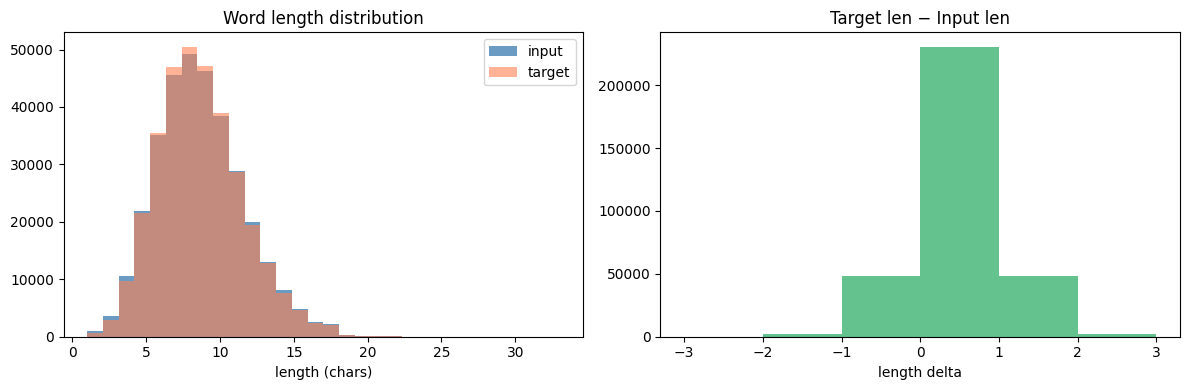

Sample pairs:
input_word target_word  input_len  target_len
 საქალლები    საქალები          9           8
შპოტსმეენი   სპოტსმენი         10           9
  პრროფილი     პროფილი          8           7
    უფოსზე     უფროსზე          6           7
  მააონეზი     მაონეზი          8           7
 ისაარლოვი    ისარლოვი          9           8
მხადგრძელს  მხარგრძელს         10          10
       საი        სადი          3           4
  გაქავედა    გაქვაედა          8           8
   სიზმრაი     სიზმარი          7           7


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['input_len'],  bins=30, color='steelblue', alpha=0.8, label='input')
axes[0].hist(df['target_len'], bins=30, color='coral',     alpha=0.6, label='target')
axes[0].set_title('Word length distribution')
axes[0].set_xlabel('length (chars)')
axes[0].legend()

diff = df['target_len'] - df['input_len']
axes[1].hist(diff, bins=range(diff.min()-1, diff.max()+2), color='mediumseagreen', alpha=0.8)
axes[1].set_title('Target len − Input len')
axes[1].set_xlabel('length delta')
plt.tight_layout()
plt.savefig('length_distribution.png', dpi=100)
plt.show()
print('Sample pairs:')
print(df[df['input_word'] != df['target_word']].sample(10, random_state=SEED).to_string(index=False))

## 4. Vocabulary & tokenisation

In [33]:
PAD_TOKEN = '<PAD>'  # 0
SOS_TOKEN = '<SOS>'  # 1
EOS_TOKEN = '<EOS>'  # 2
UNK_TOKEN = '<UNK>'  # 3

SPECIAL = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

sorted_chars = sorted(all_chars)
vocab        = SPECIAL + sorted_chars
char2idx     = {c: i for i, c in enumerate(vocab)}
idx2char     = {i: c for c, i in char2idx.items()}

PAD_IDX = char2idx[PAD_TOKEN]
SOS_IDX = char2idx[SOS_TOKEN]
EOS_IDX = char2idx[EOS_TOKEN]
UNK_IDX = char2idx[UNK_TOKEN]

VOCAB_SIZE = len(vocab)
print(f'Vocabulary size : {VOCAB_SIZE}  (4 special + {len(sorted_chars)} Georgian chars)')

def encode(word: str) -> list[int]:
    return [char2idx.get(c, UNK_IDX) for c in word]

def decode(indices) -> str:
    result = []
    for i in indices:
        if i == EOS_IDX:
            break
        if i not in (PAD_IDX, SOS_IDX):
            result.append(idx2char.get(i, ''))
    return ''.join(result)

# Persist vocab for inference notebook
vocab_data = {'char2idx': char2idx, 'idx2char': {str(k): v for k,v in idx2char.items()}}
with open('vocab.json', 'w', encoding='utf-8') as f:
    json.dump(vocab_data, f, ensure_ascii=False, indent=2)
print('Vocabulary saved to vocab.json')

Vocabulary size : 42  (4 special + 38 Georgian chars)
Vocabulary saved to vocab.json


## 5. PyTorch Dataset

In [34]:
MAX_LEN = 40   # clips extreme outliers (>99.9 % of words are shorter)

class SpellDataset(Dataset):
    def __init__(self, dataframe):
        self.pairs = []
        for _, row in dataframe.iterrows():
            inp = encode(row['input_word'])[:MAX_LEN]
            tgt = encode(row['target_word'])[:MAX_LEN]
            self.pairs.append((inp, tgt))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        inp, tgt = self.pairs[idx]
        return torch.tensor(inp, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)


def collate_fn(batch):
    """Pads inputs/targets and adds SOS/EOS to decoder sequences."""
    inputs, targets = zip(*batch)

    # Encoder: pad inputs
    input_lens = torch.tensor([len(s) for s in inputs])
    enc_padded  = nn.utils.rnn.pad_sequence(inputs,  batch_first=True, padding_value=PAD_IDX)

    # Decoder input: [SOS] + target
    dec_inputs  = [torch.cat([torch.tensor([SOS_IDX]), t]) for t in targets]
    # Decoder target: target + [EOS]
    dec_targets = [torch.cat([t, torch.tensor([EOS_IDX])]) for t in targets]

    dec_in_padded  = nn.utils.rnn.pad_sequence(dec_inputs,  batch_first=True, padding_value=PAD_IDX)
    dec_tgt_padded = nn.utils.rnn.pad_sequence(dec_targets, batch_first=True, padding_value=PAD_IDX)

    return enc_padded, input_lens, dec_in_padded, dec_tgt_padded


# Train / val / test split  (80 / 10 / 10)
df_shuffled = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
n           = len(df_shuffled)
n_train     = int(0.80 * n)
n_val       = int(0.10 * n)

df_train = df_shuffled.iloc[:n_train]
df_val   = df_shuffled.iloc[n_train : n_train + n_val]
df_test  = df_shuffled.iloc[n_train + n_val :]

print(f'Train {len(df_train):,}  |  Val {len(df_val):,}  |  Test {len(df_test):,}')

BATCH_SIZE  = 256
train_ds = SpellDataset(df_train)
val_ds   = SpellDataset(df_val)
test_ds  = SpellDataset(df_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)
print(f'Train batches: {len(train_loader)}')

Train 265,705  |  Val 33,213  |  Test 33,214
Train batches: 1038


## 6. Model architecture

**Why encoder–decoder with attention?**  
Output length may differ from input length (insertions / deletions), which rules out a simple  
many-to-many model of equal length. The encoder–decoder naturally handles this:  
the encoder reads the full corrupted word, and the decoder generates one corrected character  
at a time until it emits `<EOS>`.  

**Why Bidirectional GRU for the encoder?**  
Seeing both past and future characters helps the model decide whether a character is an error  
(e.g. a transposed pair is only recognisable when both neighbours are visible simultaneously).  

**Why Bahdanau attention?**  
Allows the decoder to selectively focus on the relevant part of the source sequence at each step,  
which is crucial when the alignment between input and output characters is monotonic but  
occasionally shifts due to insertions/deletions.

In [35]:
class BahdanauAttention(nn.Module):
    """Additive (Bahdanau) attention."""
    def __init__(self, enc_hidden: int, dec_hidden: int, attn_dim: int = 128):
        super().__init__()
        self.W_enc = nn.Linear(enc_hidden * 2, attn_dim, bias=False)  # bi-dir
        self.W_dec = nn.Linear(dec_hidden,      attn_dim, bias=False)
        self.v     = nn.Linear(attn_dim, 1,               bias=False)

    def forward(self, encoder_outputs, decoder_hidden, src_mask=None):
        """
        encoder_outputs : (B, S, enc_hidden*2)
        decoder_hidden  : (B, dec_hidden)
        src_mask        : (B, S)  — True where PAD
        Returns
            context     : (B, enc_hidden*2)
            weights     : (B, S)
        """
        energy = torch.tanh(
            self.W_enc(encoder_outputs) +              # (B, S, attn_dim)
            self.W_dec(decoder_hidden).unsqueeze(1)    # (B, 1, attn_dim)
        )                                              # (B, S, attn_dim)
        scores = self.v(energy).squeeze(-1)            # (B, S)
        if src_mask is not None:
            scores = scores.masked_fill(src_mask, float('-inf'))
        weights = F.softmax(scores, dim=-1)            # (B, S)
        context = torch.bmm(weights.unsqueeze(1),      # (B, 1, S)
                            encoder_outputs            # (B, S, H)
                            ).squeeze(1)               # (B, H)
        return context, weights


class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn       = nn.GRU(
            emb_dim, hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.dropout   = nn.Dropout(dropout)
        # Project bidirectional hidden → decoder hidden (one direction)
        self.fc        = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, src, src_lens):
            """
            src      : (B, S)
            src_lens : (B,)
            Returns
                outputs : (B, S, hidden*2)
                hidden  : (1, B, hidden)  — for decoder initialisation
            """
            embedded = self.dropout(self.embedding(src))          # (B, S, emb)
            
            packed   = pack_padded_sequence(
                embedded, src_lens.cpu(),
                batch_first=True, enforce_sorted=False
            )
            packed_out, hidden = self.rnn(packed)
            outputs, _ = pad_packed_sequence(packed_out, batch_first=True)
            
            # rnn hidden shape: (2 * n_layers, B, hidden_dim)
            total_layers = hidden.size(0) // 2
            
            # 1. Isolate the forward and backward hidden states of the very LAST layer
            # Forward final state is at index: 2 * (total_layers - 1)
            # Backward final state is at index: 2 * (total_layers - 1) + 1
            fwd_last = hidden[2 * (total_layers - 1)]
            bwd_last = hidden[2 * (total_layers - 1) + 1]
            
            # 2. Concatenate them along the feature dimension -> (B, hidden_dim * 2)
            last_layer_merged = torch.cat([fwd_last, bwd_last], dim=-1)
            
            # 3. Project down from (hidden_dim * 2) to (hidden_dim) and add non-linearity
            projected_hidden = torch.tanh(self.fc(last_layer_merged)) # (B, hidden_dim)
            
            # 4. Reshape to meet Decoder requirements -> (1, B, hidden_dim)
            hidden = projected_hidden.unsqueeze(0)  
            
            return outputs, hidden


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden, dec_hidden, n_layers, dropout, attn_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding  = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention  = BahdanauAttention(enc_hidden, dec_hidden, attn_dim)
        self.rnn        = nn.GRU(
            emb_dim + enc_hidden * 2,   # emb + context
            dec_hidden,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.dropout    = nn.Dropout(dropout)
        self.out        = nn.Linear(dec_hidden + enc_hidden*2 + emb_dim, vocab_size)

    def forward_step(self, token, hidden, encoder_outputs, src_mask):
        """
        token           : (B,)
        hidden          : (1, B, dec_hidden)
        encoder_outputs : (B, S, enc_hidden*2)
        Returns logits (B, vocab), new hidden
        """
        embedded = self.dropout(self.embedding(token)).unsqueeze(1)  # (B,1,emb)
        context, _ = self.attention(encoder_outputs,
                                    hidden[-1],          # (B, dec_hidden)
                                    src_mask)
        rnn_input  = torch.cat([embedded, context.unsqueeze(1)], dim=-1)  # (B,1,emb+ctx)
        output, hidden = self.rnn(rnn_input, hidden)
        # output: (B, 1, dec_hidden)
        combined = torch.cat([
            output.squeeze(1),
            context,
            embedded.squeeze(1)
        ], dim=-1)                                        # (B, dec_h+ctx+emb)
        logits = self.out(combined)                       # (B, vocab)
        return logits, hidden


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, src_lens, trg, teacher_forcing_ratio=0.5):
        """
        src    : (B, S)
        src_lens: (B,)
        trg    : (B, T)   — [SOS, c1, c2, ..., cN]  (decoder input)
        Returns logits (B, T, vocab)
        """
        B, T       = trg.size()
        enc_out, hidden = self.encoder(src, src_lens)       # (B,S,H*2), (1,B,H)
        src_mask   = (src == PAD_IDX)                       # (B, S)

        outputs    = torch.zeros(B, T, self.decoder.vocab_size, device=src.device)
        token      = trg[:, 0]                              # SOS

        for t in range(1, T):
            logits, hidden = self.decoder.forward_step(token, hidden, enc_out, src_mask)
            outputs[:, t] = logits
            # Teacher forcing
            use_teacher = (random.random() < teacher_forcing_ratio)
            token = trg[:, t] if use_teacher else logits.argmax(-1)

        return outputs   # (B, T, vocab)

In [36]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
EMB_DIM      = 64
HIDDEN_DIM   = 256
ATTN_DIM     = 128
N_LAYERS     = 2
DROPOUT      = 0.3
LABEL_SMOOTH = 0.1

encoder = Encoder(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = Decoder(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM, HIDDEN_DIM, 1, DROPOUT, ATTN_DIM)
model   = Seq2Seq(encoder, decoder).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Trainable parameters: 2,587,946


## 7. Training utilities

In [37]:
def label_smoothed_ce(logits, targets, smoothing=0.1, ignore_index=PAD_IDX):
    """
    logits  : (B*T, V)
    targets : (B*T,)
    """
    V      = logits.size(-1)
    log_p  = F.log_softmax(logits, dim=-1)
    # Standard CE on non-pad tokens
    ce     = F.nll_loss(log_p, targets, ignore_index=ignore_index, reduction='sum')
    # Smooth component
    mask   = (targets != ignore_index)
    smooth = -log_p[mask].sum() / V
    n      = mask.sum().float()
    loss   = (1 - smoothing) * ce / n + smoothing * smooth / n
    return loss


def word_accuracy(logits, dec_targets):
    """
    Proportion of words where every character is predicted correctly.
    logits      : (B, T, V)
    dec_targets : (B, T)   — target + EOS
    """
    preds = logits.argmax(-1)          # (B, T)
    # Mask padding in targets
    mask  = (dec_targets != PAD_IDX)   # (B, T)
    # A word is correct iff every non-pad position matches
    match_per_pos = (preds == dec_targets) | ~mask   # (B, T)
    correct_words = match_per_pos.all(dim=1).float() # (B,)
    return correct_words.mean().item()


def train_epoch(model, loader, optimiser, scheduler, tf_ratio, clip=1.0):
    model.train()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0
    for enc_in, enc_lens, dec_in, dec_tgt in loader:
        enc_in  = enc_in.to(DEVICE)
        enc_lens = enc_lens.to(DEVICE)
        dec_in  = dec_in.to(DEVICE)
        dec_tgt = dec_tgt.to(DEVICE)

        optimiser.zero_grad()
        logits = model(enc_in, enc_lens, dec_in, tf_ratio)   # (B, T, V)

        B, T, V = logits.shape
        loss = label_smoothed_ce(
            logits[:, 1:].reshape(-1, V),
            dec_tgt[:, 1:].reshape(-1),
            smoothing=LABEL_SMOOTH
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimiser.step()

        total_loss += loss.item()
        total_acc  += word_accuracy(logits[:, 1:], dec_tgt[:, 1:])
        n_batches  += 1

    scheduler.step()
    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0
    for enc_in, enc_lens, dec_in, dec_tgt in loader:
        enc_in   = enc_in.to(DEVICE)
        enc_lens = enc_lens.to(DEVICE)
        dec_in   = dec_in.to(DEVICE)
        dec_tgt  = dec_tgt.to(DEVICE)

        logits = model(enc_in, enc_lens, dec_in, teacher_forcing_ratio=0.0)
        B, T, V = logits.shape
        loss = label_smoothed_ce(
            logits[:, 1:].reshape(-1, V),
            dec_tgt[:, 1:].reshape(-1),
            smoothing=LABEL_SMOOTH
        )
        total_loss += loss.item()
        total_acc  += word_accuracy(logits[:, 1:], dec_tgt[:, 1:])
        n_batches  += 1
    return total_loss / n_batches, total_acc / n_batches

## 8. Training loop

In [38]:
# ── Optimiser & scheduler ──────────────────────────────────────────────────────
EPOCHS        = 30
LR            = 3e-3
PATIENCE      = 5
MODEL_PATH    = 'georgian_spellchecker.pt'

optimiser = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS, eta_min=1e-5)

# Teacher-forcing ratio schedule: start at 1.0, decay to 0.5
def get_tf_ratio(epoch, total):
    return max(0.5, 1.0 - 0.5 * epoch / (total * 0.6))

# ── Training ──────────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss  = float('inf')
patience_count = 0

print(f'{"Epoch":>5}  {"TF":>5}  {"Train Loss":>10}  {"Val Loss":>10}  {"Train Acc":>10}  {"Val Acc":>10}  {"Time":>7}')
print('-' * 70)

for epoch in range(1, EPOCHS + 1):
    tf = get_tf_ratio(epoch, EPOCHS)
    t0 = time.time()

    tr_loss, tr_acc = train_epoch(model, train_loader, optimiser, scheduler, tf)
    vl_loss, vl_acc = eval_epoch(model, val_loader)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    elapsed = time.time() - t0
    print(f'{epoch:5d}  {tf:5.2f}  {tr_loss:10.4f}  {vl_loss:10.4f}  '
          f'{tr_acc:10.4f}  {vl_acc:10.4f}  {elapsed:6.1f}s')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_count = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optim_state': optimiser.state_dict(),
            'val_loss'   : vl_loss,
            'val_acc'    : vl_acc,
            'hparams'    : dict(
                emb_dim=EMB_DIM, hidden_dim=HIDDEN_DIM, attn_dim=ATTN_DIM,
                n_layers=N_LAYERS, dropout=DROPOUT, vocab_size=VOCAB_SIZE
            )
        }, MODEL_PATH)
        print(f'         ✓ New best saved  (val_loss={vl_loss:.4f})')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
            break

print(f'\nTraining complete. Best val loss: {best_val_loss:.4f}')

Epoch     TF  Train Loss    Val Loss   Train Acc     Val Acc     Time
----------------------------------------------------------------------
    1   0.97      1.2425      1.7905      0.3525      0.0778    72.0s
         ✓ New best saved  (val_loss=1.7905)
    2   0.94      1.0855      1.6913      0.4624      0.1399    71.7s
         ✓ New best saved  (val_loss=1.6913)
    3   0.92      1.1035      1.4735      0.4560      0.2133    71.6s
         ✓ New best saved  (val_loss=1.4735)
    4   0.89      1.1403      1.4663      0.4360      0.1946    71.1s
         ✓ New best saved  (val_loss=1.4663)
    5   0.86      1.1330      1.4560      0.4434      0.1998    70.7s
         ✓ New best saved  (val_loss=1.4560)
    6   0.83      1.1475      1.4348      0.4364      0.1973    70.2s
         ✓ New best saved  (val_loss=1.4348)
    7   0.81      1.1544      1.3748      0.4345      0.3290    70.8s
         ✓ New best saved  (val_loss=1.3748)
    8   0.78      1.1582      1.3380      0.4369      

## 9. Loss & accuracy curves

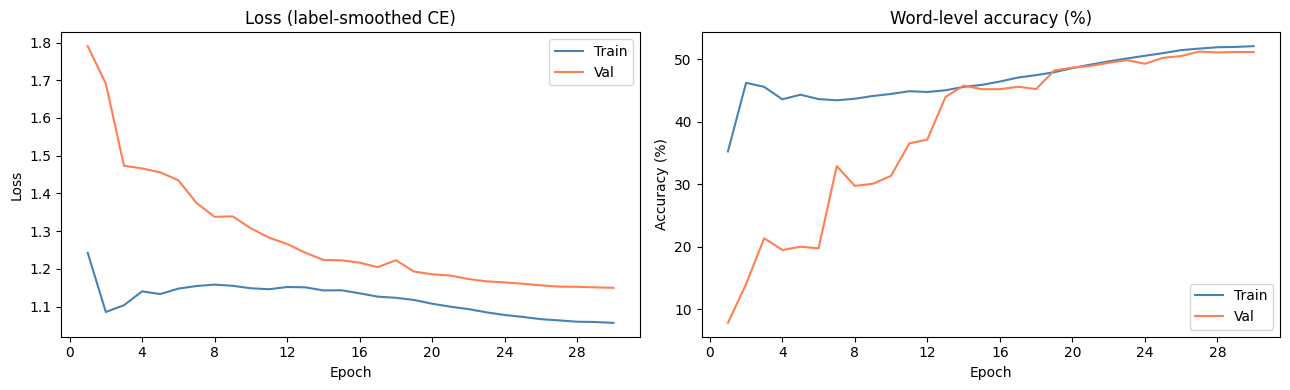

In [39]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(x, history['val_loss'],   label='Val',   color='coral')
axes[0].set_title('Loss (label-smoothed CE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[1].plot(x, [a*100 for a in history['train_acc']], label='Train', color='steelblue')
axes[1].plot(x, [a*100 for a in history['val_acc']],   label='Val',   color='coral')
axes[1].set_title('Word-level accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100)
plt.show()

## 10. Greedy & beam-search decoding

In [40]:
# Load best checkpoint
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}  "
      f"(val_loss={checkpoint['val_loss']:.4f}, val_acc={checkpoint['val_acc']:.4f})")


@torch.no_grad()
def greedy_decode(word: str, max_len: int = MAX_LEN + 5) -> str:
    """Greedy (argmax) decoding for a single word."""
    src    = torch.tensor(encode(word), dtype=torch.long).unsqueeze(0).to(DEVICE)
    src_len = torch.tensor([src.size(1)])
    enc_out, hidden = model.encoder(src, src_len)
    src_mask = (src == PAD_IDX)

    token   = torch.tensor([SOS_IDX], device=DEVICE)
    result  = []
    for _ in range(max_len):
        logits, hidden = model.decoder.forward_step(token, hidden, enc_out, src_mask)
        token = logits.argmax(-1)
        if token.item() == EOS_IDX:
            break
        result.append(token.item())
    return decode(result)


@torch.no_grad()
def beam_decode(word: str, beam_width: int = 5, max_len: int = MAX_LEN + 5) -> str:
    """Beam-search decoding for a single word."""
    src     = torch.tensor(encode(word), dtype=torch.long).unsqueeze(0).to(DEVICE)
    src_len = torch.tensor([src.size(1)])
    enc_out, hidden = model.encoder(src, src_len)
    src_mask = (src == PAD_IDX)

    # Each beam: (log_prob, token_list, hidden)
    beams = [(0.0, [SOS_IDX], hidden)]
    completed = []

    for _ in range(max_len):
        candidates = []
        for log_prob, tokens, h in beams:
            if tokens[-1] == EOS_IDX:
                completed.append((log_prob, tokens))
                continue
            token  = torch.tensor([tokens[-1]], device=DEVICE)
            logits, new_h = model.decoder.forward_step(token, h, enc_out, src_mask)
            lp     = F.log_softmax(logits, dim=-1).squeeze(0)
            topk   = lp.topk(beam_width)
            for score, idx in zip(topk.values.tolist(), topk.indices.tolist()):
                candidates.append((log_prob + score, tokens + [idx], new_h))
        if not candidates:
            break
        beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_width]

    completed += [(lp, toks) for lp, toks, _ in beams]
    best = max(completed, key=lambda x: x[0])
    return decode(best[1][1:])   # skip SOS

Loaded checkpoint from epoch 30  (val_loss=1.1497, val_acc=0.5117)


## 11. Test-set evaluation

In [41]:
test_loss, test_acc = eval_epoch(model, test_loader)
print(f'Test loss : {test_loss:.4f}')
print(f'Test word accuracy (teacher-forced, greedy): {test_acc*100:.2f}%')

# Free-running word accuracy on 2000 random test samples
sample_test = df_test.sample(min(2000, len(df_test)), random_state=SEED)
correct_greedy = 0
correct_beam   = 0
for _, row in sample_test.iterrows():
    pred_g = greedy_decode(row['input_word'])
    pred_b = beam_decode(row['input_word'])
    correct_greedy += (pred_g == row['target_word'])
    correct_beam   += (pred_b == row['target_word'])

n_s = len(sample_test)
print(f'Free-running greedy accuracy (n={n_s}): {100*correct_greedy/n_s:.2f}%')
print(f'Free-running beam   accuracy (n={n_s}): {100*correct_beam/n_s:.2f}%')

Test loss : 1.1492
Test word accuracy (teacher-forced, greedy): 50.95%
Free-running greedy accuracy (n=2000): 0.05%
Free-running beam   accuracy (n=2000): 0.05%


## 12. Qualitative demonstration — 30 examples

In [42]:
# Mix: 15 error pairs + 15 already-correct words
errors_sample  = df_test[df_test['input_word'] != df_test['target_word']].sample(15, random_state=SEED)
correct_sample = df_test[df_test['input_word'] == df_test['target_word']].sample(15, random_state=SEED)
demo           = pd.concat([errors_sample, correct_sample]).sample(frac=1, random_state=SEED)

rows = []
for _, row in demo.iterrows():
    pred = beam_decode(row['input_word'])
    ok   = '✓' if pred == row['target_word'] else '✗'
    rows.append({
        'Input'   : row['input_word'],
        'Target'  : row['target_word'],
        'Prediction': pred,
        'Result'  : ok
    })

demo_df = pd.DataFrame(rows)
print(demo_df.to_string(index=False))
print(f"\nCorrect: {(demo_df['Result']=='✓').sum()} / {len(demo_df)}")

            Input            Target       Prediction Result
          ჩარეულა           ჩარეულა           არეულა      ✗
              ბობ               ბობ               ობ      ✗
           ანსიპი            ანსიპი            ნსიპი      ✗
          წამებაა           წამებაა           ამებაა      ✗
      იკნოჟურნალი       კინოჟურნალი       იოოჟურნალი      ✗
            რონის             რომის             ონის      ✗
მთავარმოწამისადმი მთავარმოწამისადმი თავარმოწამისადმი      ✗
           იყვირა            იყვირა            ყვირა      ✗
          ზალალმა           ზარალმა           ალალმა      ✗
          ხაენინე           ხეანინე           აენინე      ✗
         იგრძნოგა          იგრძნობა          გრძნნგა      ✗
        ცალმხრივი         ცალმხრივი         ალმხრივი      ✗
        ბაპტიმორი         ბალტიმორი         აპტიმორი      ✗
         იმჰყნვენ          მიჰყვნენ          იჰყნვენ      ✗
        ბერვალლდი          ბერვალდი          ერვალდი      ✗
             სესე              სესე     

## 13. Save model & artefacts

In [43]:
print(f'Model saved to  : {MODEL_PATH}')
print(f'Vocabulary saved: vocab.json')
print(f'Plots saved     : length_distribution.png, training_curves.png')

# Confirm the checkpoint is loadable
ck = torch.load(MODEL_PATH, map_location='cpu')
print(f"Checkpoint keys : {list(ck.keys())}")
print(f"Best epoch      : {ck['epoch']}")
print(f"Best val loss   : {ck['val_loss']:.4f}")
print(f"Best val acc    : {ck['val_acc']:.4f}")

Model saved to  : georgian_spellchecker.pt
Vocabulary saved: vocab.json
Plots saved     : length_distribution.png, training_curves.png
Checkpoint keys : ['epoch', 'model_state', 'optim_state', 'val_loss', 'val_acc', 'hparams']
Best epoch      : 30
Best val loss   : 1.1497
Best val acc    : 0.5117
